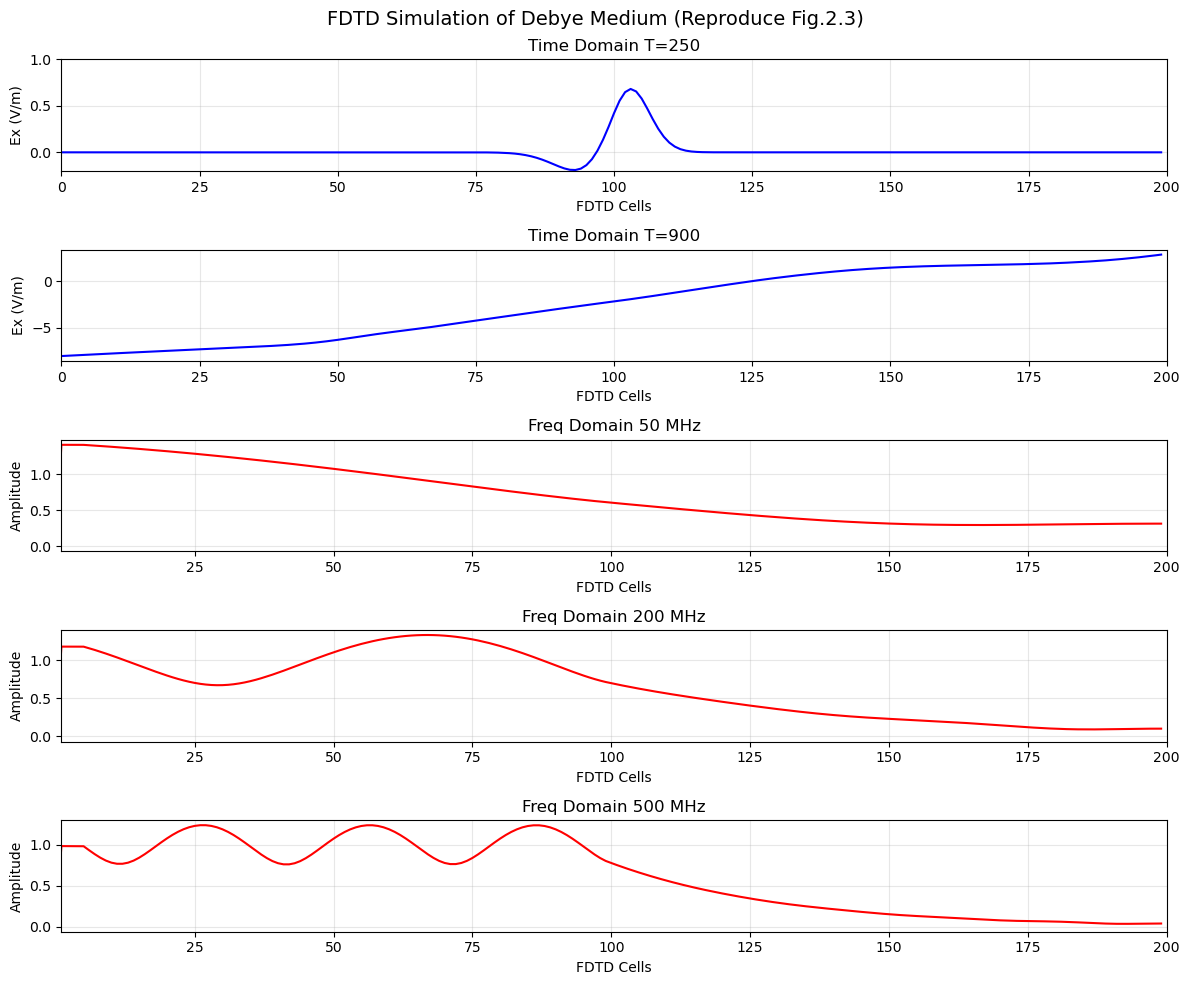

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 基础参数初始化
KE = 200                # 网格总数
epsz = 8.8e-12          # 真空介电常数
pi = 3.14159
c = 3e8                 # 光速
ddx = 0.01              # 空间步长
dt = ddx / 6e8          # 时间步长，满足CFL条件
t0 = 50.0               # 高斯脉冲中心时间
spread = 10.0           # 高斯脉冲展宽

# 2. 介质参数（对应图2.3的Debye介质）
epsilon = 2.0           # 相对介电常数
sigma = 0.01            # 电导率
chi1 = 2.0              # 极化系数
tau = 0.001e-6          # 弛豫时间，0.001微秒转秒
del_exp = np.exp(-dt / tau)  # 指数衰减因子
kstart = 100            # 介质起始网格位置（从中间开始）

# 3. 频域计算参数
freq_list = np.array([50e6, 200e6, 500e6])  # 仿真频率点
num_freq = len(freq_list)
arg = 2 * pi * freq_list * dt               # 频域相位因子

# 4. 数组初始化
dx = np.zeros(KE)       # 电通量密度
ex = np.zeros(KE)       # 电场强度
hy = np.zeros(KE)       # 磁场强度
ix = np.zeros(KE)       # 电导率相关辅助量
sx = np.zeros(KE)       # Debye模型极化辅助量

# 频域实部、虚部数组
real_pt = np.zeros((num_freq, KE))
imag_pt = np.zeros((num_freq, KE))
real_in = np.zeros(num_freq)  # 输入脉冲频域实部
imag_in = np.zeros(num_freq)  # 输入脉冲频域虚部

# 介质参数数组
ga = np.ones(KE)        # 电场计算系数
gb = np.zeros(KE)       # ix更新系数
gc = np.zeros(KE)       # sx更新系数

# 5. 设置介质区域参数
for k in range(kstart, KE):
    ga[k] = 1.0 / (epsilon + sigma * dt / epsz + chi1 * dt / tau)
    gb[k] = sigma * dt / epsz
    gc[k] = chi1 * dt / tau

# 边界条件辅助变量
ex_low_m1 = 0.0
ex_low_m2 = 0.0
ex_high_m1 = 0.0
ex_high_m2 = 0.0

# 6. 时域主循环
nsteps_total = 1000  # 总时间步数，覆盖T=250和T=1000
ex_record = []  # 记录不同时刻的电场
t_record = [250, 900]

for n in range(1, nsteps_total + 1):
    # 6.1 更新电通量密度dx
    for k in range(1, KE):
        dx[k] += 0.5 * (hy[k-1] - hy[k])
    
    # 6.2 加入高斯脉冲源（位置在k=5）
    pulse = np.exp(-0.5 * ((t0 - n) / spread) ** 2)
    dx[5] += pulse
    
    # 6.3 更新电场ex、辅助量ix和sx
    for k in range(KE - 1):
        ex[k] = ga[k] * (dx[k] - ix[k] - del_exp * sx[k])
        ix[k] += gb[k] * ex[k]
        sx[k] = del_exp * sx[k] + gc[k] * ex[k]
    
    # 6.4 计算频域响应（实部、虚部累加）
    for k in range(KE):
        for m in range(num_freq):
            real_pt[m, k] += ex[k] * np.cos(arg[m] * n)
            imag_pt[m, k] -= ex[k] * np.sin(arg[m] * n)
    
    # 6.5 记录输入脉冲的频域响应（前3*t0步）
    if n < 3 * t0:
        for m in range(num_freq):
            real_in[m] += ex[10] * np.cos(arg[m] * n)
            imag_in[m] -= ex[10] * np.sin(arg[m] * n)
    
    # 6.6 边界条件（二阶吸收边界）
    ex[0] = ex_low_m2
    ex_low_m2 = ex_low_m1
    ex_low_m1 = ex[1]
    
    ex[KE-1] = ex_high_m2
    ex_high_m2 = ex_high_m1
    ex_high_m1 = ex[KE-2]
    
    # 6.7 更新磁场hy
    for k in range(KE - 1):
        hy[k] += 0.5 * (ex[k] - ex[k+1])
    
    # 6.8 记录指定时刻的电场
    if n in t_record:
        ex_record.append(ex.copy())

# 7. 计算频域幅度（归一化）
ampn = np.zeros((num_freq, KE))
for m in range(num_freq):
    amp_in = np.sqrt(real_in[m] ** 2 + imag_in[m] ** 2)
    for k in range(KE):
        ampn[m, k] = np.sqrt(real_pt[m, k] ** 2 + imag_pt[m, k] ** 2) / amp_in

# 8. 绘图：复现图2.3的(a)(b)(c)
fig, axes = plt.subplots(5, 1, figsize=(12, 10))
fig.suptitle('FDTD Simulation of Debye Medium (Reproduce Fig.2.3)', fontsize=14)

# 8.1 绘制时域电场（T=250和T=1000）
for idx, t in enumerate(t_record):
    ax = axes[idx]
    if idx == 0:
        ax.plot(np.arange(KE), ex_record[idx], 'b-')
    else:
        ax.plot(np.arange(KE), ex_record[idx]*1000, 'b-')
    ax.set_title(f'Time Domain T={t}')
    ax.set_xlabel('FDTD Cells')
    ax.set_ylabel('Ex (V/m)')
    ax.set_xlim(0, 200)
    ax.grid(alpha=0.3)
    if idx == 0:  # 对应 T=250 的图
        ax.set_ylim(-0.2, 1)

# 8.2 绘制频域幅度（50/200/500 MHz）
freq_labels = ['50 MHz', '200 MHz', '500 MHz']
for m in range(num_freq):
    ax = axes[m+2]
    ax.plot(np.arange(KE), ampn[m], 'r-')
    ax.set_title(f'Freq Domain {freq_labels[m]}')
    ax.set_xlabel('FDTD Cells')
    ax.set_ylabel('Amplitude')
    ax.set_xlim(1, 200)
    ax.grid(alpha=0.3)


plt.tight_layout()
plt.show()

In [25]:
# ========== 补充：计算三个频率下的有效介电常数和电导率 ==========
# 1. 定义参数和频率
epsilon = 2.0
sigma = 0.01
chi1 = 2.0
tau = 0.001e-6  # 弛豫时间 0.001微秒
eps0 = 8.8e-12
freq_list = np.array([50e6, 200e6, 500e6])

# 2. 初始化结果数组
eps_eff_real = []  # 有效介电常数（实部）
sigma_eff = []     # 有效电导率

# 3. 逐个频率计算
for f in freq_list:
    omega = 2 * np.pi * f  # 角频率
    omega_tau = omega * tau
    denom = 1 + (omega_tau) ** 2
    
    # 计算复数介电常数的实部和虚部
    eps_real = epsilon + chi1 / denom
    eps_imag = - (sigma / (omega * eps0) + (chi1 * omega_tau) / denom)
    
    # 有效介电常数 = 实部；有效电导率 = ωε0|虚部|
    eps_eff_real.append(eps_real)
    sigma_eff.append(omega * eps0 * abs(eps_imag))

# 4. 输出结果
print("===== 不同频率下的有效介电常数和电导率 =====")
for i, f in enumerate(freq_list):
    print(f"频率: {f/1e6:.0f} MHz | 有效介电常数: {eps_eff_real[i]:.2f} | 有效电导率: {sigma_eff[i]:.4f} S/m")

===== 不同频率下的有效介电常数和电导率 =====
频率: 50 MHz | 有效介电常数: 3.82 | 有效电导率: 0.0116 S/m
频率: 200 MHz | 有效介电常数: 2.78 | 有效电导率: 0.0208 S/m
频率: 500 MHz | 有效介电常数: 2.18 | 有效电导率: 0.0260 S/m
